# Controller Testing

Currently broken, not sure why openrocket_data.csv can't be read after fixing the Controls import

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# --- Bootstrap imports so your local package is picked up and reloaded ---
from pathlib import Path
import sys, importlib, os

# 1) Ensure the repo parent is on sys.path (..../<parent>/Maurice2)
repo_parent = Path.cwd().resolve().parents[1]  # workspace -> Maurice2 -> parent
if str(repo_parent) not in sys.path:
    sys.path.insert(0, str(repo_parent))

# 2) (Optional) If you want to override the data dir at runtime, set this:
# os.environ["MAURICE2_DATA_DIR"] = str(Path(repo_parent, "Maurice2", "data"))

# 3) Autoreload to pick up edits to Maurice2/*
%load_ext autoreload
%autoreload 2

# 4) Import (or reload) your class
from Maurice2.controls import control_algorithm
importlib.reload(control_algorithm)  # ensure your __file__ change is active
from Maurice2.controls.control_algorithm import Controls


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
## Define gain matrix ##
K_pre_max = 1.75
K_pre_min = 2.5e-1

K_post_max = 1.0
K_post_min = 2.5e-1

pre_width = 5
post_width = 8

pre_v3_mid = 90.0
post_v3_mid = 90.0

## Define initial conditions ##
t0 = 0.0
xhat0 = np.array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0]) # Initial state estimate
u0 = np.array([0])
sampling_rate = 20.0  # Hz
dt = 1.0 / sampling_rate

controller = Controls(dt=dt, x0=xhat0, u0=u0, t_launch_rail_clearance=0.308)
controller.deriveEOM(post_burnout=False)
controller.deriveEOM(post_burnout=True)
controller.set_K_params(K_pre_max=K_pre_max, K_pre_min=K_pre_min,
                        K_post_max=K_post_max, K_post_min=K_post_min,
                        pre_width=pre_width, post_width=post_width,
                        pre_v3_mid=pre_v3_mid, post_v3_mid=post_v3_mid)
controller.buildL(lw=5.0, lqw=1.0, lqx=2.0, lqy=2.0, lqz=2.0)
controller.run_rk4(t0, xhat0, u0)

t: 0.050
t: 0.100
t: 0.150
t: 0.200
t: 0.250
t: 0.300
t: 0.350
t: 0.400
t: 0.450
t: 0.500
t: 0.550
t: 0.600
t: 0.650
t: 0.700
t: 0.750
t: 0.800
t: 0.850
t: 0.900
t: 0.950
t: 1.000
t: 1.050
t: 1.100
t: 1.150
t: 1.200
t: 1.250
t: 1.300
t: 1.350
t: 1.400
t: 1.450
t: 1.500
t: 1.550
t: 1.600
t: 1.650
t: 1.700
t: 1.750
t: 1.800
t: 1.850
t: 1.900
t: 1.950
t: 2.000
t: 2.050
t: 2.100
t: 2.150
t: 2.200
t: 2.250
t: 2.300
t: 2.350
t: 2.400
t: 2.450
t: 2.500
t: 2.550
t: 2.600
t: 2.650
t: 2.700
t: 2.750
t: 2.800
t: 2.850
t: 2.900
t: 2.950
t: 3.000
t: 3.050
t: 3.100
t: 3.150
t: 3.200
t: 3.250
t: 3.300
t: 3.350
t: 3.400
t: 3.450
t: 3.500
t: 3.550
t: 3.600
t: 3.650
t: 3.700
t: 3.750
t: 3.800
t: 3.850
t: 3.900
t: 3.950
t: 4.000
t: 4.050
t: 4.100
t: 4.150
t: 4.200
t: 4.250
t: 4.300
t: 4.350
t: 4.400
t: 4.450
t: 4.500
t: 4.550
t: 4.600
t: 4.650
t: 4.700
t: 4.750
t: 4.800
t: 4.850
t: 4.900
t: 4.950
t: 5.000
t: 5.050
t: 5.100
t: 5.150
t: 5.200
t: 5.250
t: 5.300
t: 5.350
t: 5.400
t: 5.450
t: 5.500
t: 5.550
t

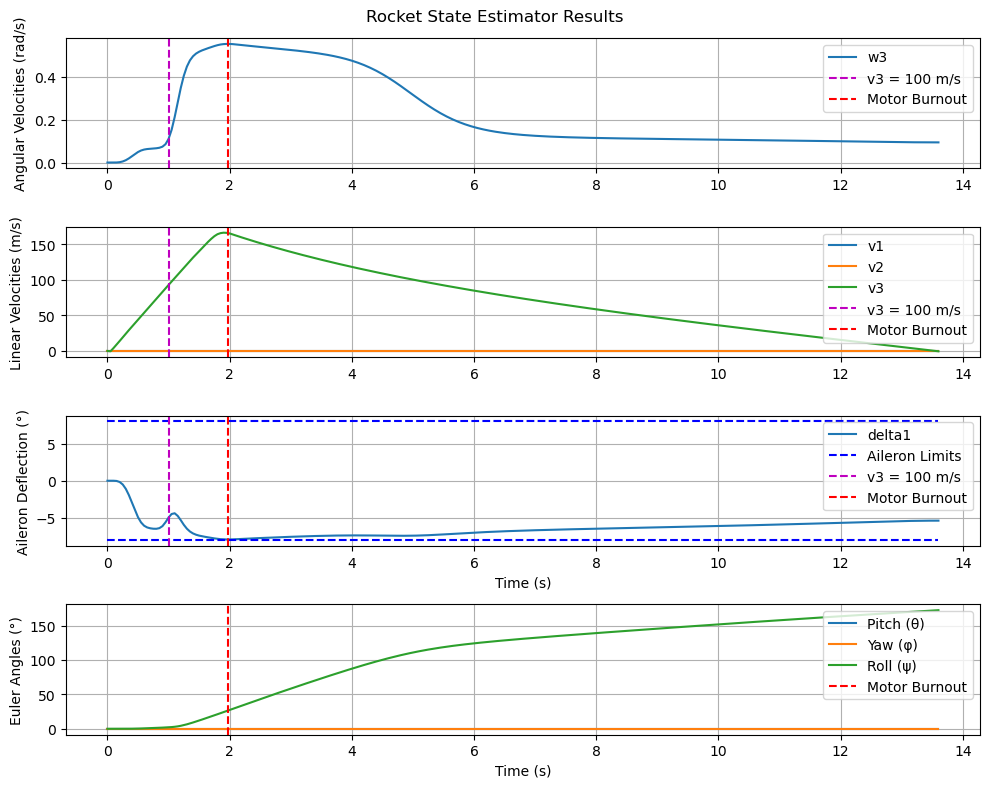

In [22]:
xhat = np.array(controller.states)
u = np.array(controller.inputs)
t = np.arange(0, xhat.shape[0]*controller.dt, controller.dt)

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=False)
fig.suptitle('Rocket State Estimator Results')
# axs[0].plot(t, xhat[:, 0], label='w1')
# axs[0].plot(t, xhat[:, 1], label='w2')
axs[0].plot(t, xhat[:, 2], label='w3')
# axs[0].set_ylim([-1e-3, 1e-2])
v3_100_index = np.where(xhat[:, 5] >= pre_v3_mid)[0]
v3_100_time = v3_100_index[0] * controller.dt
axs[0].axvline(v3_100_time, color='m', linestyle='--', label='v3 = 100 m/s')
axs[0].axvline(controller.t_motor_burnout, color='r', linestyle='--', label='Motor Burnout')
axs[0].set_ylabel('Angular Velocities (rad/s)')
axs[0].legend(loc='upper right')
axs[0].grid()
axs[1].plot(t, xhat[:, 3], label='v1')
axs[1].plot(t, xhat[:, 4], label='v2')
axs[1].plot(t, xhat[:, 5], label='v3')
axs[1].axvline(v3_100_time, color='m', linestyle='--', label='v3 = 100 m/s')
axs[1].axvline(controller.t_motor_burnout, color='r', linestyle='--', label='Motor Burnout')
axs[1].set_ylabel('Linear Velocities (m/s)')
axs[1].legend(loc='upper right')
axs[1].grid()
axs[2].plot(t, u * 180/np.pi, label='delta1')
axs[2].plot(t, -8 * np.ones_like(u), 'b--', label='Aileron Limits')
axs[2].plot(t, 8 * np.ones_like(u), 'b--')
axs[2].axvline(v3_100_time, color='m', linestyle='--', label='v3 = 100 m/s')
axs[2].axvline(controller.t_motor_burnout, color='r', linestyle='--', label='Motor Burnout')
axs[2].set_ylabel('Aileron Deflection (°)')
axs[2].set_xlabel('Time (s)')
axs[2].legend(loc='upper right')
axs[2].grid()

# Convert quaternion to Euler angles for plotting
euler_angles = np.array([controller.quat_to_euler_xyz(q) for q in xhat[:, 6:10]])
axs[3].plot(t, np.rad2deg(euler_angles[:, 0]), label='Pitch (θ)')
axs[3].plot(t, np.rad2deg(euler_angles[:, 1]), label='Yaw (φ)')
axs[3].plot(t, np.rad2deg(euler_angles[:, 2]), label='Roll (ψ)')
axs[3].axvline(controller.t_motor_burnout, color='r', linestyle='--', label='Motor Burnout')
axs[3].set_ylabel('Euler Angles (°)')
axs[3].set_xlabel('Time (s)')
axs[3].legend(loc='upper right')
axs[3].grid()
plt.tight_layout()

# # Alternative: Plot quaternion components ##
# axs[3].plot(t, xhat[:, 6], label='qw')
# axs[3].plot(t, xhat[:, 7], label='qx')
# axs[3].plot(t, xhat[:, 8], label='qy')
# axs[3].plot(t, xhat[:, 9], label='qz')
# axs[3].axvline(controller.t_motor_burnout, color='r', linestyle='--', label='Motor Burnout')
# axs[3].set_ylabel('Quaternion Components')
# axs[3].set_xlabel('Time (s)')
# axs[3].legend()
# axs[3].grid()
# plt.tight_layout()

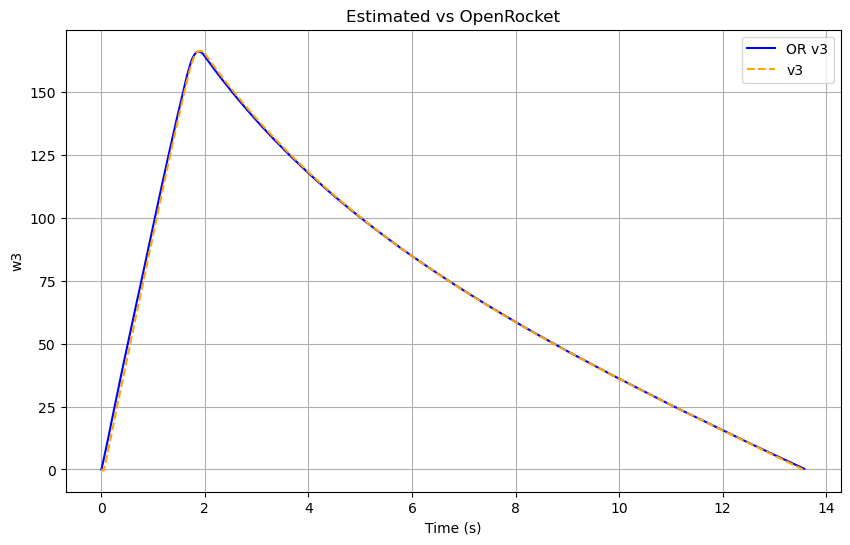

In [23]:
# Compare with OpenRocket data
import pandas as pd
openrocket_data = pd.read_csv(controller.csv_path)
time = openrocket_data['# Time (s)']
mask = time <= t[-1]
plt.figure(figsize=(10, 6))
plt.plot(time[mask], openrocket_data['Vertical velocity (m/s)'][mask], label='OR v3', color='blue')
# plt.plot(openrocket_data['# Time (s)'], openrocket_data['Roll rate (°/s)'], label='OR v3', color='blue')
plt.plot(t, xhat[:, 5], label='v3', color='orange', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('w3')
plt.title('Estimated vs OpenRocket')
plt.legend()
plt.grid()
plt.show()